**Why two separate curves** — the loss function needs different behavior depending on the true label:
- When $y=1$: loss should be near 0 if the model predicts close to 1 (confident and correct), and blow up toward $\infty$ if the model predicts close to 0 (confident and *wrong*).
- When $y=0$: the opposite — loss near 0 if prediction is close to 0, blowing up if prediction is close to 1.

$-\log(f)$ and $-\log(1-f)$ are exactly the two functions with this shape. Plotting them side by side makes this visible directly.

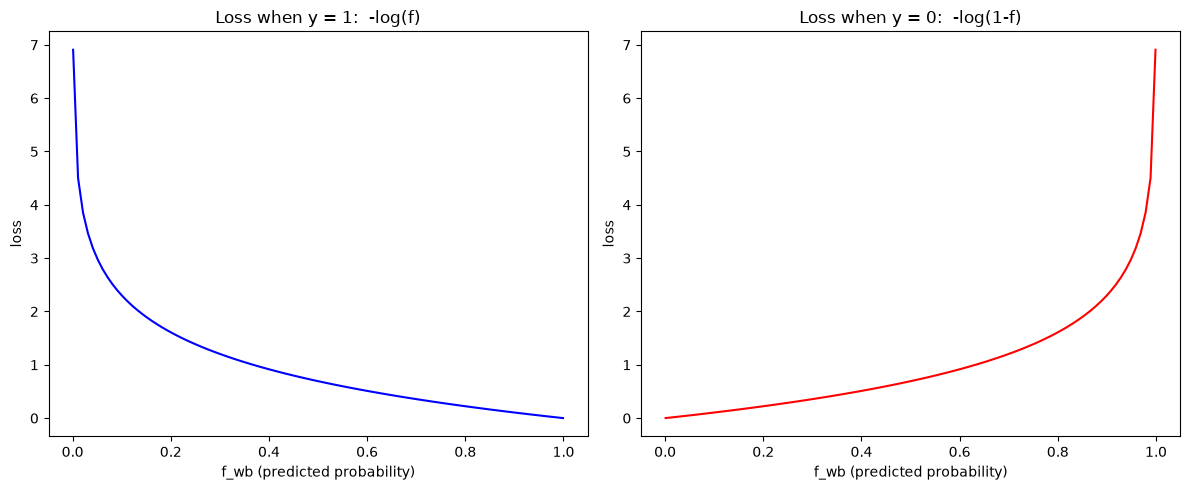

In [1]:
import numpy as np
import matplotlib.pyplot as plt

f = np.linspace(0.001, 0.999, 100)   # avoid exactly 0 or 1 — log(0) is undefined

loss_y1 = -np.log(f)          # loss when y=1
loss_y0 = -np.log(1 - f)      # loss when y=0

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(f, loss_y1, color='blue')
axes[0].set_xlabel('f_wb (predicted probability)')
axes[0].set_ylabel('loss')
axes[0].set_title('Loss when y = 1:  -log(f)')

axes[1].plot(f, loss_y0, color='red')
axes[1].set_xlabel('f_wb (predicted probability)')
axes[1].set_ylabel('loss')
axes[1].set_title('Loss when y = 0:  -log(1-f)')

plt.tight_layout()
plt.show()

**Why logistic regression doesn't reuse linear regression's cost** — squared error, $\big(f_{\mathbf{w},b}(x)-y\big)^2$, when combined with the *sigmoid* function inside it, produces a cost surface $J(\mathbf{w},b)$ that's **non-convex** — it has multiple local minima. Gradient descent can get stuck in a local minimum instead of finding the true (global) minimum.

Log loss, by contrast, produces a **convex** cost surface — one global minimum, guaranteeing gradient descent converges to the correct answer (given a reasonable $\alpha$). This single-variable comparison below shows the shape difference directly, holding $y=1$ fixed and varying the prediction $f$.

In [ ]:
f = np.linspace(0.001, 0.999, 100)
y = 1

squared_error_loss = (f - y) ** 2
log_loss = -np.log(f)

plt.figure(figsize=(8, 5))
plt.plot(f, squared_error_loss, color='orange', label='Squared error: (f-y)^2')
plt.plot(f, log_loss, color='blue', label='Log loss: -log(f)')
plt.xlabel('f_wb (predicted probability)')
plt.ylabel('loss')
plt.title('Squared Error vs Log Loss (y=1)')
plt.legend()
plt.show()

**Why combine into one line** — the piecewise definition is clear for understanding, but awkward to code (needs an if/else per example). Since $y$ is always either 0 or 1, this algebraic trick combines both cases into a single expression — when $y=1$, the second term multiplies by 0 and vanishes; when $y=0$, the first term vanishes:

$$loss\big(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}\big) = -y^{(i)}\log\big(f_{\mathbf{w},b}(\mathbf{x}^{(i)})\big) - (1-y^{(i)})\log\big(1-f_{\mathbf{w},b}(\mathbf{x}^{(i)})\big)$$

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss_single(f_wb, y):
    """Verifies the combined formula matches the piecewise definition for one example."""
    return -y * np.log(f_wb) - (1 - y) * np.log(1 - f_wb)

# check the combined formula reduces to the correct piece for both y cases
f_example = 0.8
print(f"y=1: combined = {compute_loss_single(f_example, 1):.4f}, piecewise (-log(f)) = {-np.log(f_example):.4f}")
print(f"y=0: combined = {compute_loss_single(f_example, 0):.4f}, piecewise (-log(1-f)) = {-np.log(1-f_example):.4f}")

y=1: combined = 0.2231, piecewise (-log(f)) = 0.2231
y=0: combined = 1.6094, piecewise (-log(1-f)) = 1.6094


**From single-example loss to full cost** — a single example's loss (Chunk 3) only tells you how wrong the model was on *that one point*. To train the model, you need the cost function $J(\mathbf{w},b)$: the loss averaged across the *entire* training set.

$$J(\mathbf{w},b) = \frac{1}{m}\sum_{i=0}^{m-1} loss\big(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}\big)$$

Same structural pattern as `compute_cost` for linear regression earlier in this conversation: loop over `i`, compute the prediction (`z_i` then `f_wb_i` via sigmoid), accumulate the per-example loss, then divide by `m` once — outside the loop — at the end.

**`np.dot(X[i], w)`** — dot product of example `i`'s feature row with `w`, giving $\mathbf{w}\cdot\mathbf{x}^{(i)}$, a scalar. Same operation as linear regression's `f_wb = np.dot(X[i], w) + b`, just fed through `sigmoid()` afterward here.

In [4]:
def compute_cost_logistic(X, y, w, b):
    """
    Computes cost
    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters  
      b (scalar)       : model parameter
      
    Returns:
      cost (scalar): cost
    """
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        z_i = np.dot(X[i], w) + b        # z^(i) = w . x^(i) + b
        f_wb_i = sigmoid(z_i)             # f_wb^(i) = g(z^(i)), the sigmoid prediction
        cost += -y[i]*np.log(f_wb_i) - (1-y[i])*np.log(1-f_wb_i)   # combined loss formula from Chunk 3
             
    cost = cost / m                       # average over all m examples — completes J(w,b)
    return cost

# quick sanity check on a tiny toy dataset
X_toy = np.array([[1.0], [2.0], [3.0]])
y_toy = np.array([0, 0, 1])
w_toy = np.array([0.5])
b_toy = -1.0

print(f"Cost on toy data: {compute_cost_logistic(X_toy, y_toy, w_toy, b_toy):.4f}")

Cost on toy data: 0.5471
